# Binary MLP Training with PyTorch

This notebook trains a binary multilayer perceptron on the processed student depression dataset.

It uses a proper train/validation/test split, a PyTorch implementation of the MLP, and evaluation metrics to compare performance across splits.

In [ ]:
# Global setup and reproducibility
from pathlib import Path
import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Training hyperparameters (tweak these as needed)
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 25

# Adam-specific hyperparameters (configurable)

_BETAS = (0.9, 0.999)
ADAM_EPS = 1e-8
ADAM_AMSGRAD = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Using device: {device}")

Project root: C:\Users\irira\Documents\Efrei\ING2\S8\Convex Optimization\Project\Convex-Optimization
Using device: cpu


In [2]:
# Load processed data and convert target to 0/1 for PyTorch
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "clean_student_data.csv"

df = pd.read_csv(DATA_PATH)
if "Depression" not in df.columns:
    raise KeyError("Expected a Depression target column in the processed CSV.")

X = df.drop(columns=["Depression"]).to_numpy(dtype=np.float32)
y = df["Depression"].map({-1: 0, 1: 1}).to_numpy(dtype=np.float32)
feature_names = [col for col in df.columns if col != "Depression"]

print(f"Dataset shape: {df.shape}")
print(f"Feature count: {len(feature_names)}")
print("Class distribution:")
print(pd.Series(y.astype(int)).value_counts().sort_index())
print(df.head())

Dataset shape: (100000, 18)
Feature count: 17
Class distribution:
0    89938
1    10062
Name: count, dtype: int64
        Age      CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0  0.495403  0.772553        0.262011    -0.612083           -0.069468   
1 -0.504411 -0.228120       -0.909858     1.361535            1.679202   
2 -0.504411  0.305063       -0.974962    -1.118139           -1.145572   
3 -0.004504  1.444970        0.265221    -1.269956            0.737610   
4 -1.004318  0.544076       -0.063508    -0.966322            0.535841   

   Physical_Activity  Stress_Level  Transportation_Time  Student_Debt  \
0           0.914222      0.609728             0.480073             0   
1           1.559878     -1.496801            -0.666320             0   
2           1.444582     -0.794625             0.265124             1   
3           1.283168     -0.794625             1.411518             1   
4          -1.622284      1.311904            -0.021474             0   

  

In [3]:
# Train / validation / test split
from sklearn.model_selection import train_test_split

TEST_RATIO = 0.15
VAL_RATIO = 0.15
RANDOM_STATE = 42

# First split off the test set.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Split the remaining data into train and validation.
val_size_relative = VAL_RATIO / (1.0 - TEST_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_size_relative,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print("\nClass balance:")
print(f"Train: {np.bincount(y_train.astype(int))}")
print(f"Validation: {np.bincount(y_val.astype(int))}")
print(f"Test: {np.bincount(y_test.astype(int))}")

Train shape: (69999, 17)
Validation shape: (15001, 17)
Test shape: (15000, 17)

Class balance:
Train: [62955  7044]
Validation: [13492  1509]
Test: [13491  1509]


In [ ]:
# Model definition and loaders
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

class BinaryMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers=(64, 32), dropout=0.0):
        super().__init__()
        layers = []
        layer_sizes = [input_dim, *hidden_layers]

        for in_features, out_features in zip(layer_sizes[:-1], layer_sizes[1:]):
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))

        layers.append(nn.Linear(layer_sizes[-1], 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(1)


def make_loader(X_array, y_array, batch_size=128, shuffle=False):
    tensor_X = torch.from_numpy(X_array).float()
    tensor_y = torch.from_numpy(y_array).float()
    dataset = TensorDataset(tensor_X, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

model = BinaryMLP(
    input_dim=X_train.shape[1],
    hidden_layers=(64, 32),
    dropout=0.1,
).to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=ADAM_BETAS,
    eps=ADAM_EPS,
    amsgrad=ADAM_AMSGRAD,
)

print(model)
print(f"Using device: {device}")

BinaryMLP(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Using device: cpu


In [5]:
# Training loop

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        probs = model(batch_X)
        loss = criterion(probs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        preds = (probs >= 0.5).long()
        correct += (preds == batch_y.long()).sum().item()
        total += batch_X.size(0)

    return running_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            probs = model(batch_X)
            loss = criterion(probs, batch_y)
            running_loss += loss.item() * batch_X.size(0)
            preds = (probs >= 0.5).long()
            correct += (preds == batch_y.long()).sum().item()
            total += batch_X.size(0)

    return running_loss / total, correct / total

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_loss = float("inf")
best_state = None
patience = 5
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch} epochs.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best validation model.")

Epoch 01/25 | train_loss=0.3280 train_acc=0.8992 | val_loss=0.3074 val_acc=0.8994
Epoch 02/25 | train_loss=0.3097 train_acc=0.8994 | val_loss=0.3046 val_acc=0.8996
Epoch 03/25 | train_loss=0.3070 train_acc=0.8993 | val_loss=0.3024 val_acc=0.8995
Epoch 04/25 | train_loss=0.3053 train_acc=0.8995 | val_loss=0.3024 val_acc=0.8995
Epoch 05/25 | train_loss=0.3039 train_acc=0.8994 | val_loss=0.3009 val_acc=0.8991
Epoch 06/25 | train_loss=0.3036 train_acc=0.8995 | val_loss=0.3001 val_acc=0.8993
Epoch 07/25 | train_loss=0.3027 train_acc=0.8993 | val_loss=0.2994 val_acc=0.8993
Epoch 08/25 | train_loss=0.3021 train_acc=0.8995 | val_loss=0.2995 val_acc=0.8991
Epoch 09/25 | train_loss=0.3006 train_acc=0.8993 | val_loss=0.2994 val_acc=0.8993
Epoch 10/25 | train_loss=0.3008 train_acc=0.8994 | val_loss=0.2984 val_acc=0.8991
Epoch 11/25 | train_loss=0.3006 train_acc=0.8993 | val_loss=0.2983 val_acc=0.8992
Epoch 12/25 | train_loss=0.2995 train_acc=0.8995 | val_loss=0.2981 val_acc=0.8993
Epoch 13/25 | tr

Train metrics: {'loss': 0.2963026049386641, 'accuracy': 0.8997557107958685}
Validation metrics: {'loss': 0.29731813597246837, 'accuracy': 0.8993400439970669}
Test metrics: {'loss': 0.29853401216665904, 'accuracy': 0.8992666666666667}

Test classification report:
               precision    recall  f1-score   support

No Depression       0.90      1.00      0.95     13491
   Depression       0.47      0.01      0.02      1509

     accuracy                           0.90     15000
    macro avg       0.69      0.51      0.49     15000
 weighted avg       0.86      0.90      0.85     15000



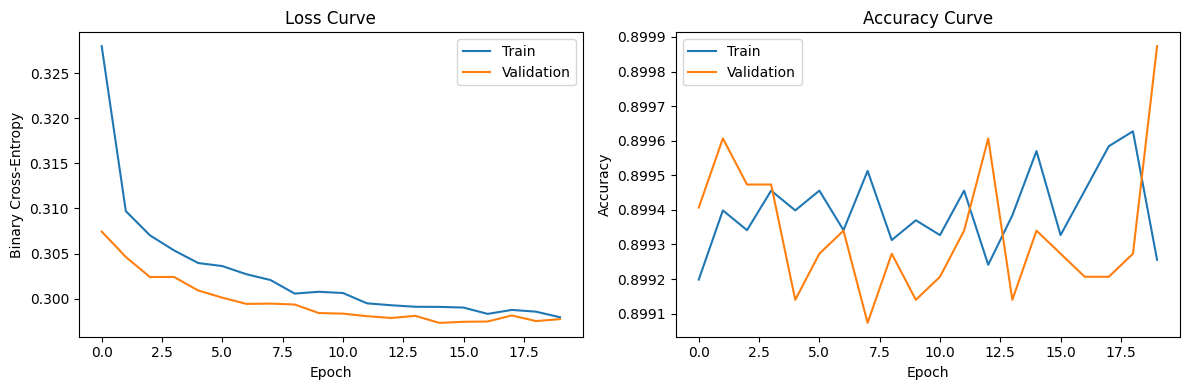

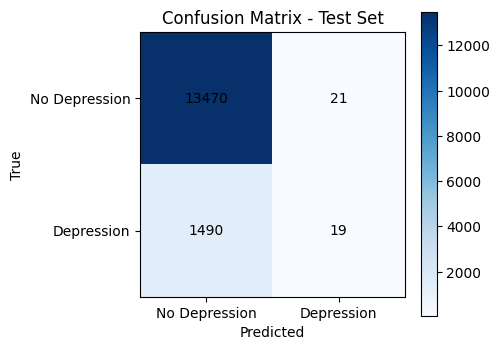

Displayed plots and metrics in the notebook.


In [6]:
# Evaluation and visualizations

def evaluate_split(model, loader):
    model.eval()
    all_probs = []
    all_preds = []
    all_targets = []
    total_loss = 0.0
    criterion = nn.BCELoss()

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            probs = model(batch_X)
            loss = criterion(probs, batch_y)
            total_loss += loss.item() * batch_X.size(0)
            all_probs.append(probs.cpu().numpy())
            all_preds.append((probs >= 0.5).long().cpu().numpy())
            all_targets.append(batch_y.long().cpu().numpy())

    y_prob = np.concatenate(all_probs)
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(y_true, y_pred)
    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

train_eval = evaluate_split(model, train_loader)
val_eval = evaluate_split(model, val_loader)
test_eval = evaluate_split(model, test_loader)

print("Train metrics:", {k: v for k, v in train_eval.items() if k not in {"y_true", "y_pred", "y_prob"}})
print("Validation metrics:", {k: v for k, v in val_eval.items() if k not in {"y_true", "y_pred", "y_prob"}})
print("Test metrics:", {k: v for k, v in test_eval.items() if k not in {"y_true", "y_pred", "y_prob"}})

print("\nTest classification report:")
print(classification_report(test_eval["y_true"], test_eval["y_pred"], target_names=["No Depression", "Depression"], zero_division=0))

# Loss / accuracy curves
history_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["train_loss"], label="Train")
axes[0].plot(history_df["val_loss"], label="Validation")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()

axes[1].plot(history_df["train_acc"], label="Train")
axes[1].plot(history_df["val_acc"], label="Validation")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

fig.tight_layout()
plt.show()

# Confusion matrix (display only)
cm = confusion_matrix(test_eval["y_true"], test_eval["y_pred"])
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.xticks([0, 1], ["No Depression", "Depression"])
plt.yticks([0, 1], ["No Depression", "Depression"])
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), value in np.ndenumerate(cm):
    plt.text(j, i, int(value), ha="center", va="center", color="black")
plt.colorbar()
plt.tight_layout()
plt.show()


summary = {
    "train": {k: v for k, v in train_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "validation": {k: v for k, v in val_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "test": {k: v for k, v in test_eval.items() if k not in {"y_true", "y_pred", "y_prob"}}
}

print("Displayed plots and metrics in the notebook.")

In [8]:
# Save the trained model and metadata
MODEL_SAVE_DIR = PROJECT_ROOT / "src" / "models"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_SAVE_DIR / "binary_mlp_pytorch.pt"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "input_dim": X_train.shape[1],
    "hidden_layers": (64, 32),
    "dropout": 0.1,
    "feature_names": feature_names,
    "train_metrics": {k: v for k, v in train_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "validation_metrics": {k: v for k, v in val_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "test_metrics": {k: v for k, v in test_eval.items() if k not in {"y_true", "y_pred", "y_prob"}},
    "seed": SEED,
}

torch.save(checkpoint, MODEL_SAVE_PATH)
print(f"Saved model checkpoint to: {MODEL_SAVE_PATH}")

Saved model checkpoint to: C:\Users\irira\Documents\Efrei\ING2\S8\Convex Optimization\Project\Convex-Optimization\src\models\binary_mlp_pytorch.pt
